Importation des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

Chargement des Données

In [2]:
df = pd.read_excel("../data/credit.xls", header=1)
# header=1 car la première ligne du fichier UCI est un titre
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


Informations générales

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

valeurs manquantes

In [4]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


Distribution de la cible

C:\Users\edene\AppData\Local\Temp\ipykernel_27420\2983363847.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette="coolwarm")


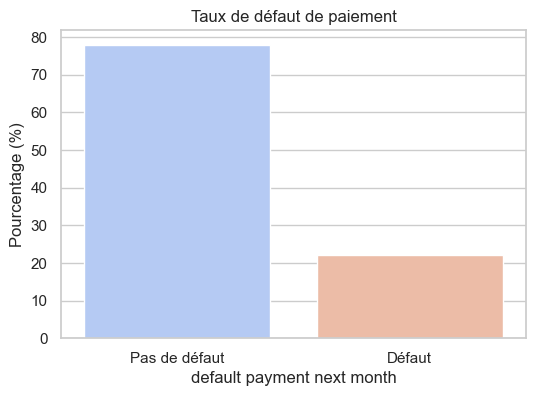

In [5]:
target_counts = df['default payment next month'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette="coolwarm")
plt.xticks([0, 1], ['Pas de défaut', 'Défaut'])
plt.ylabel("Pourcentage (%)")
plt.title("Taux de défaut de paiement")
plt.savefig("../visuals/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

Distribution des âges

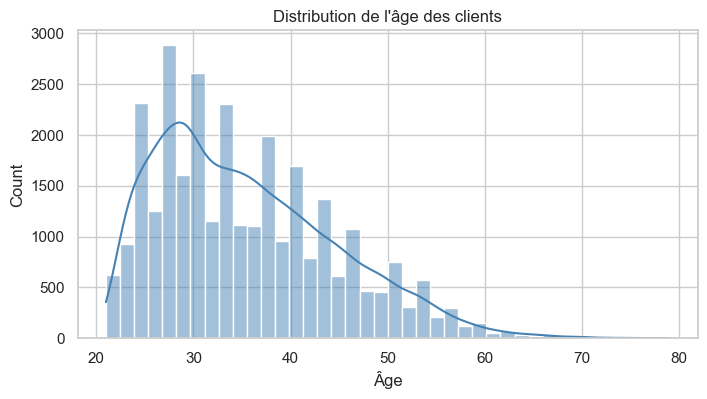

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df['AGE'], bins=40, kde=True, color="steelblue")
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.savefig("../visuals/age_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

Défaut par sexe

C:\Users\edene\AppData\Local\Temp\ipykernel_27420\3385748042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SEX', y='default payment next month', data=df, palette="coolwarm")


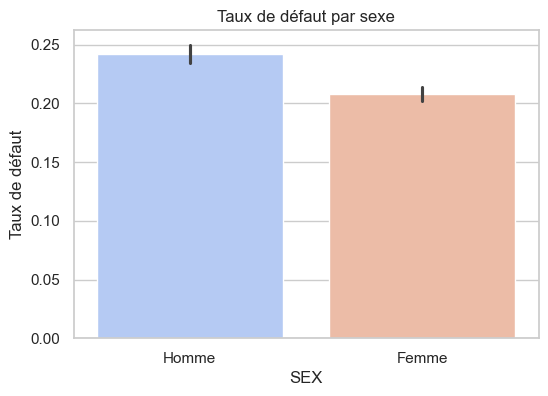

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(x='SEX', y='default payment next month', data=df, palette="coolwarm")
plt.xticks([0, 1], ['Homme', 'Femme'])
plt.ylabel("Taux de défaut")
plt.title("Taux de défaut par sexe")
plt.savefig("../visuals/default_by_sex.png", dpi=150, bbox_inches='tight')
plt.show()

Matrice de corrélation

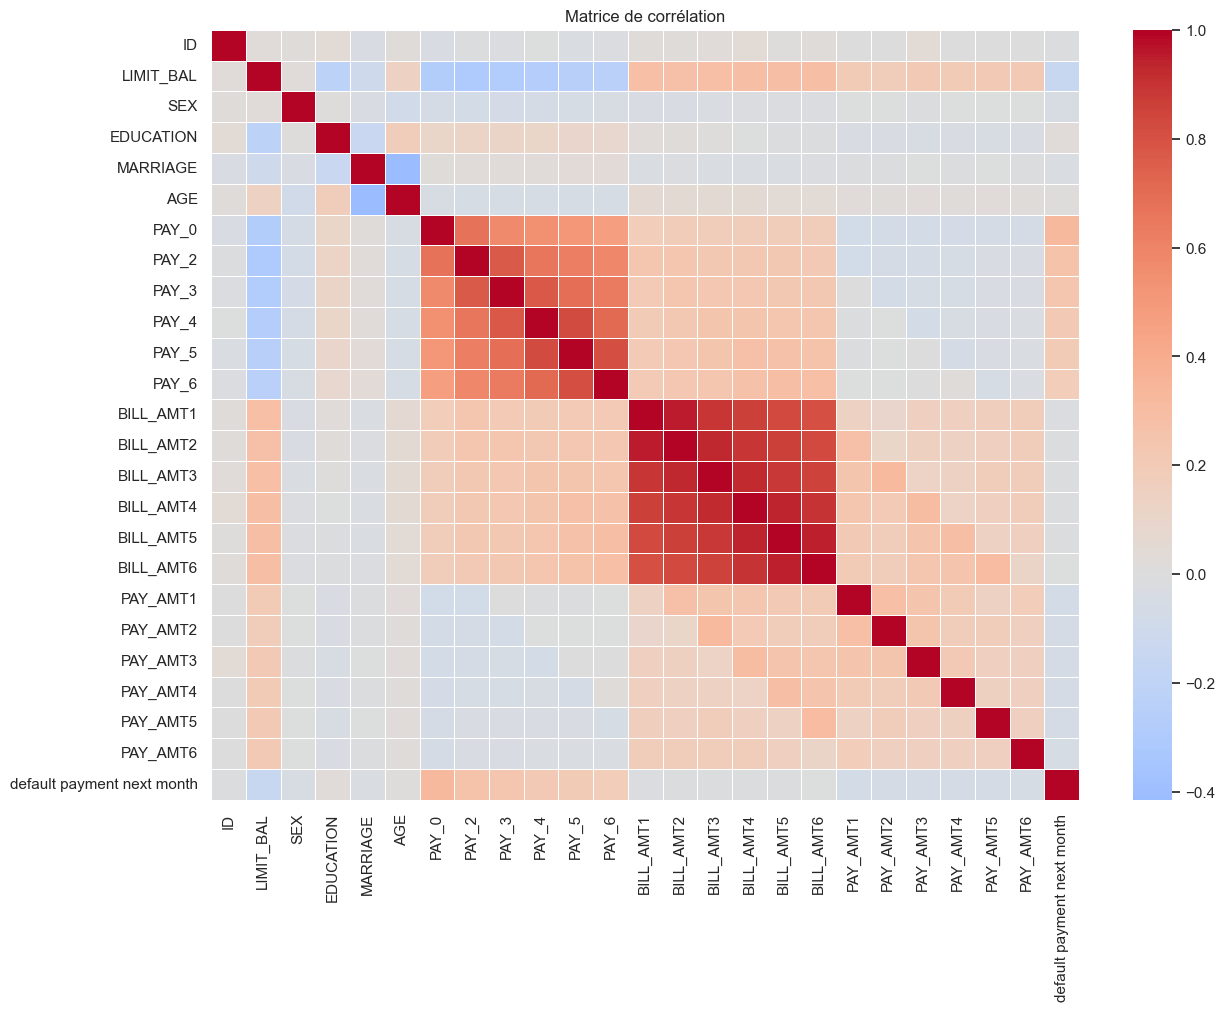

In [8]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matrice de corrélation")
plt.savefig("../visuals/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()